# 8x8 Grid


In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ibm-runtime

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit.visualization import *
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.quantum_info import Statevector
from numpy import pi
import numpy as np
from matplotlib import pyplot as plt

# Aer is now a separate package (qiskit-aer)
from qiskit_aer import AerSimulator

In [2]:
# N is the total number of vertices in the 2D grid
L = 8
N = L * L
l = 4 / N

In [3]:
# Compute coefficients of the coin
a = 2 / (4 + l)
b = 2 * np.sqrt(l) / (4 + l)
c = 2 * l / (4 + l)

In [4]:
C5 = np.array([
    [a - 1,  a,      a,      a,      b],
    [a,      a - 1,  a,      a,      b],
    [a,      a,      a - 1,  a,      b],
    [a,      a,      a,      a - 1,  b],
    [b,      b,      b,      b,      c - 1]
], dtype=complex)

# Embed into an 8x8 matrix for 3 qubits
C8 = np.zeros((8, 8), dtype=complex)
C8[:5, :5] = C5  # top-left block
for i in range(5, 8):
    C8[i, i] = 1

In [5]:
# Creating the gate for Coin
coin_gate = UnitaryGate(C8, label="Coin")

In [6]:
from qiskit.circuit.library import StatePreparation

coin_init = np.zeros(8, dtype=complex)
coin_init[0] = 1 / np.sqrt(4 + l)           # 000
coin_init[1] = 1 / np.sqrt(4 + l)           # 001
coin_init[2] = 1 / np.sqrt(4 + l)           # 010
coin_init[3] = 1 / np.sqrt(4 + l)           # 011
coin_init[4] = np.sqrt(l) / np.sqrt(4 + l)  # 100

coin_prep = StatePreparation(coin_init)

In [7]:
coin = QuantumRegister(3,'coin')
nodeX = QuantumRegister(3,'vertex_X')
nodeY = QuantumRegister(3,'vertex_y')
classR = ClassicalRegister(6,'measure')

one_step = QuantumCircuit(nodeX, nodeY, coin,  classR, name='ONE_STEP')
one_step.append(coin_prep, coin)

one_step.append(coin_gate, coin) # 000 + 001 + 010 + 011 + 100

one_step.draw()


»
vertex_X_0: »
            »
vertex_X_1: »
            »
vertex_X_2: »
            »
vertex_y_0: »
            »
vertex_y_1: »
            »
vertex_y_2: »
            »
    coin_0: »
            »
    coin_1: »
            »
    coin_2: »
            »
 measure: 6/»
            »
«                                                                                 »
«vertex_X_0: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_X_1: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_X_2: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_y_0: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_y_1: ─────────────────────────────────────────────────────────────────────»
«                                                                                 »
«vertex_y_2: ─────────────────────────────────────────────────────────────────────»
«            ┌───────────────────────────────────────────────────────────────────┐»
«    coin_0: ┤0                                                                  ├»
«            │                                                                   │»
«    coin_1: ┤1 State Preparation(0.49614,0.49614,0.49614,0.49614,0.12403,0,0,0) ├»
«            │                                                                   │»
«    coin_2: ┤2                                                                  ├»
«            └───────────────────────────────────────────────────────────────────┘»
« measure: 6/═════════════════════════════════════════════════════════════════════»
«                                                                                 »
«                     
«vertex_X_0: ─────────
«                     
«vertex_X_1: ─────────
«                     
«vertex_X_2: ─────────
«                     
«vertex_y_0: ─────────
«                     
«vertex_y_1: ─────────
«                     
«vertex_y_2: ─────────
«            ┌───────┐
«    coin_0: ┤0      ├
«            │       │
«    coin_1: ┤1 Coin ├
«            │       │
«    coin_2: ┤2      ├
«            └───────┘
« measure: 6/═════════
«

In [8]:
#phase oracle
phase_circuit =  QuantumCircuit(6, name=' phase oracle ')
# Mark 000000

#phase_circuit.h(0)
#phase_circuit.h(1)
#phase_circuit.h(2)
#phase_circuit.h(3)
#phase_circuit.h(4)
#phase_circuit.h(5)
phase_circuit.x(0)
phase_circuit.x(1)
phase_circuit.x(2)
phase_circuit.x(3)
phase_circuit.x(4)
#phase_circuit.x(5)
phase_circuit.h(5)
phase_circuit.mcx([0,1,2,3,4], 5)
phase_circuit.h(5)
phase_circuit.x(0)
phase_circuit.x(1)
phase_circuit.x(2)
phase_circuit.x(3)
phase_circuit.x(4)
#phase_circuit.x(5)
#phase_circuit.h(0)
#phase_circuit.h(1)
#phase_circuit.h(2)
#phase_circuit.h(3)
#phase_circuit.h(4)
#phase_circuit.h(5)
#one_step.append(phase_circuit,[0,1,2,3,4,5])
phase_circuit.draw()

┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     ├───┤  │  ├───┤
q_1: ┤ X ├──■──┤ X ├
     ├───┤  │  ├───┤
q_2: ┤ X ├──■──┤ X ├
     ├───┤  │  ├───┤
q_3: ┤ X ├──■──┤ X ├
     ├───┤  │  ├───┤
q_4: ┤ X ├──■──┤ X ├
     ├───┤┌─┴─┐├───┤
q_5: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘

In [9]:
# From 0000 to 0001 & 0100
def superposition(circuit):
    circuit.h(0)
    circuit.h(1)
    circuit.h(2)
    circuit.h(3)
    circuit.h(4)
    circuit.h(5)
superposition(one_step)
def shift(circuit):
    circuit.x(6)
    circuit.x(7)
    circuit.x(8)  #000 -> 111 + 001 -> 110 + 010 -> 101 + 011 - > 100 + 100-> 011
    circuit.mcx([0,1,6,7,8],2)
    circuit.mcx([0,6,7,8],1)
    circuit.mcx([6,7,8],0)
    circuit.x(6) #001 -> 111 , 010 -> 100, 011-> 101
    circuit.mcx([6,7,8],0)
    circuit.mcx([0,6,7,8],1)
    circuit.mcx([0,1,6,7,8],2)
    circuit.x(6)
    circuit.x(7) #010 - > 111 , 011-> 110
    circuit.mcx([3,4,6,7,8],5)
    circuit.mcx([3,6,7,8],4)
    circuit.mcx([6,7,8],3)
    circuit.x(6) # 011 - > 111
    circuit.mcx([6,7,8],3)
    circuit.mcx([3,6,7,8],4)
    circuit.mcx([3,4,6,7,8],5)
    circuit.x(8)

    circuit.x(8)
    circuit.cx(8,6)
    circuit.x(8)


shift(one_step)
one_step.append(phase_circuit,[0,1,2,3,4,5])
one_step_gate = one_step.to_instruction()
one_step.draw()

»
vertex_X_0: »
            »
vertex_X_1: »
            »
vertex_X_2: »
            »
vertex_y_0: »
            »
vertex_y_1: »
            »
vertex_y_2: »
            »
    coin_0: »
            »
    coin_1: »
            »
    coin_2: »
            »
 measure: 6/»
            »
«                                            ┌───┐                                »
«vertex_X_0: ────────────────────────────────┤ H ├────────────────────────────────»
«                                            ├───┤                                »
«vertex_X_1: ────────────────────────────────┤ H ├────────────────────────────────»
«                                            ├───┤                                »
«vertex_X_2: ────────────────────────────────┤ H ├────────────────────────────────»
«                                            ├───┤                                »
«vertex_y_0: ────────────────────────────────┤ H ├────────────────────────────────»
«                                            ├───┤                                »
«vertex_y_1: ────────────────────────────────┤ H ├────────────────────────────────»
«                                            ├───┤                                »
«vertex_y_2: ────────────────────────────────┤ H ├────────────────────────────────»
«            ┌───────────────────────────────┴───┴───────────────────────────────┐»
«    coin_0: ┤0                                                                  ├»
«            │                                                                   │»
«    coin_1: ┤1 State Preparation(0.49614,0.49614,0.49614,0.49614,0.12403,0,0,0) ├»
«            │                                                                   │»
«    coin_2: ┤2                                                                  ├»
«            └───────────────────────────────────────────────────────────────────┘»
« measure: 6/═════════════════════════════════════════════════════════════════════»
«                                                                                 »
«                                    ┌───┐     ┌───┐                         »
«vertex_X_0: ────────────────■────■──┤ X ├─────┤ X ├──■────■─────────────────»
«                            │  ┌─┴─┐└─┬─┘     └─┬─┘┌─┴─┐  │                 »
«vertex_X_1: ────────────────■──┤ X ├──┼─────────┼──┤ X ├──■─────────────────»
«                          ┌─┴─┐└─┬─┘  │         │  └─┬─┘┌─┴─┐               »
«vertex_X_2: ──────────────┤ X ├──┼────┼─────────┼────┼──┤ X ├───────────────»
«                          └─┬─┘  │    │         │    │  └─┬─┘               »
«vertex_y_0: ────────────────┼────┼────┼─────────┼────┼────┼─────────■────■──»
«                            │    │    │         │    │    │         │  ┌─┴─┐»
«vertex_y_1: ────────────────┼────┼────┼─────────┼────┼────┼─────────■──┤ X ├»
«                            │    │    │         │    │    │       ┌─┴─┐└─┬─┘»
«vertex_y_2: ────────────────┼────┼────┼─────────┼────┼────┼───────┤ X ├──┼──»
«            ┌───────┐┌───┐  │    │    │  ┌───┐  │    │    │  ┌───┐└─┬─┘  │  »
«    coin_0: ┤0      ├┤ X ├──■────■────■──┤ X ├──■────■────■──┤ X ├──■────■──»
«            │       │├───┤  │    │    │  └───┘  │    │    │  ├───┤  │    │  »
«    coin_1: ┤1 Coin ├┤ X ├──■────■────■─────────■────■────■──┤ X ├──■────■──»
«            │       │├───┤  │    │    │         │    │    │  └───┘  │    │  »
«    coin_2: ┤2      ├┤ X ├──■────■────■─────────■────■────■─────────■────■──»
«            └───────┘└───┘                                                  »
« measure: 6/════════════════════════════════════════════════════════════════»
«                                                                            »
«                                     ┌─────────────────┐               
«vertex_X_0: ─────────────────────────┤0                ├───────────────
«                                     │                 │               
«vertex_X_1: ─────────────────────────┤1                ├───────────────
«  

In [10]:
import numpy as np
x =  0.922466 * np.sqrt((N)*(np.log2(N)))
#x = 14

In [11]:
for i in range(int(x-1)):
    one_step.append(coin_gate,[6,7,8])
    shift(one_step)
    one_step.append(phase_circuit,[0,1,2,3,4,5])

In [12]:
def shift(circuit):
    circuit.x(6)
    circuit.x(7)
    circuit.x(8)  #000 -> 111 + 001 -> 110 + 010 -> 101 + 011 - > 100 + 100-> 011
    circuit.mcx([0,1,6,7,8],2)
    circuit.mcx([0,6,7,8],1)
    circuit.mcx([6,7,8],0)
    circuit.x(6) #001 -> 111 , 010 -> 100, 011-> 101
    circuit.mcx([6,7,8],0)
    circuit.mcx([0,6,7,8],1)
    circuit.mcx([0,1,6,7,8],2)
    circuit.x(6)
    circuit.x(7) #010 - > 111 , 011-> 110
    circuit.mcx([3,4,6,7,8],5)
    circuit.mcx([3,6,7,8],4)
    circuit.mcx([6,7,8],3)
    circuit.x(6) # 011 - > 111
    circuit.mcx([6,7,8],3)
    circuit.mcx([3,6,7,8],4)
    circuit.mcx([3,4,6,7,8],5)
    circuit.x(8)
    circuit.x(6)
    circuit.x(7)
    circuit.mcx([7,8],6)
    circuit.x(7)

#shift(one_step)
#one_step.append(phase_circuit,[0,1,2,3,4,5])

In [13]:
one_step.measure([0,1,2,3,4,5],[0,1,2,3,4,5])

In [14]:
#one_step.draw()

In [15]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

job = sampler.run([one_step], shots=1000)

result = job.result()

In [16]:
# First, check what attributes are available in the DataBin
print(dir(result[0].data))

['_FIELDS', '_FIELD_TYPES', '_RESTRICTED_NAMES', '_SHAPE', '__abstractmethods__', '__annotate_func__', '__annotations__', '__annotations_cache__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__non_callable_proto_members__', '__parameters__', '__protocol_attrs__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_data', '_is_protocol', '_is_runtime_protocol', '_shape', 'items', 'keys', 'measure', 'ndim', 'shape', 'size', 'values']


In [17]:
counts = result[0].data.measure.get_counts()
print(counts)

{'100000': 953, '000110': 3, '000101': 1, '011111': 1, '100111': 6, '011011': 1, '011000': 10, '010101': 1, '101101': 1, '011101': 1, '010000': 4, '101111': 3, '100001': 4, '001110': 1, '101011': 1, '011001': 1, '001101': 1, '010110': 1, '100110': 2, '110100': 1, '011010': 1, '111110': 1, '100011': 1}


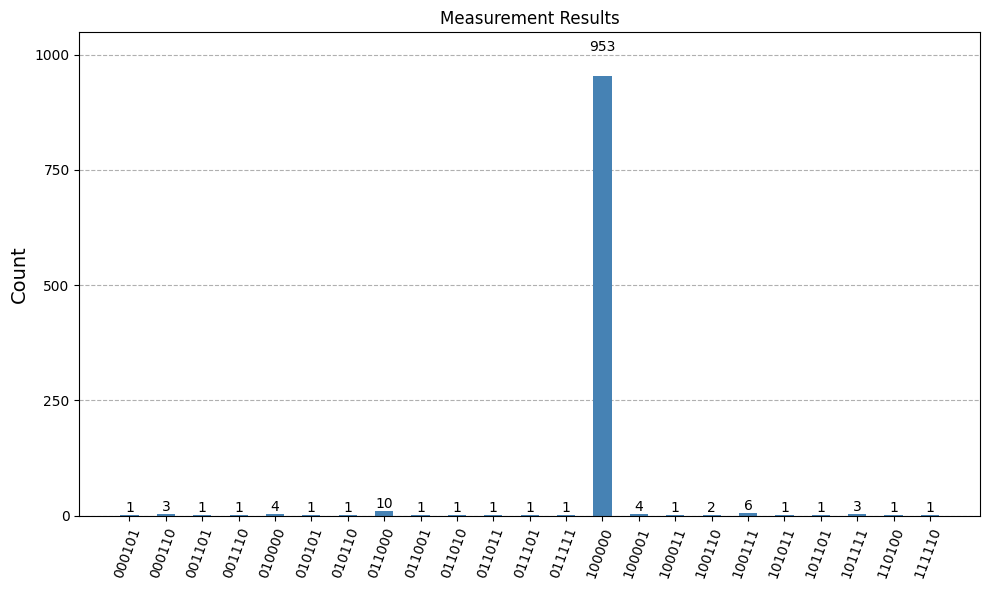

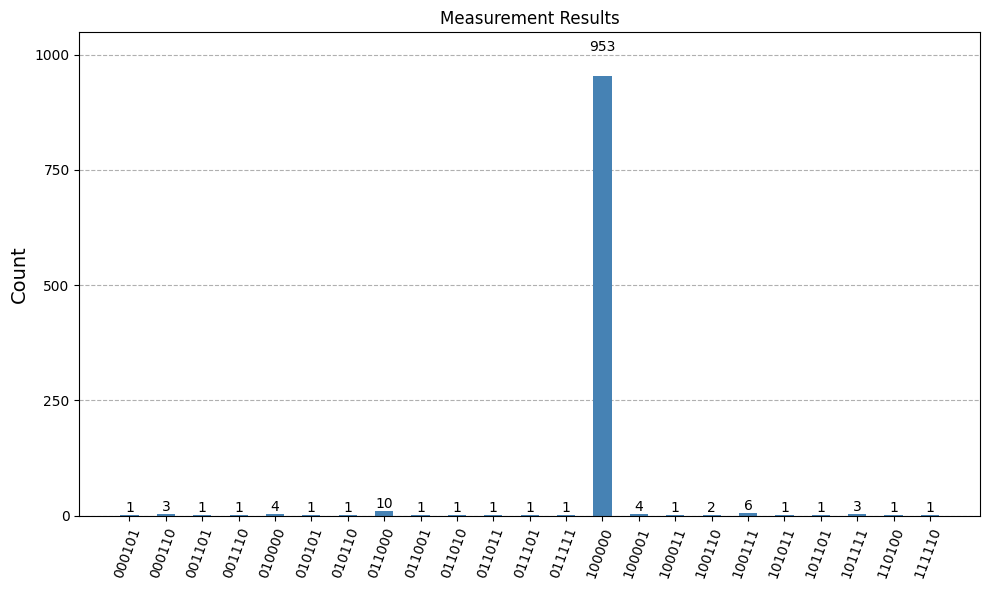

In [18]:
%matplotlib inline
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig = plot_histogram(counts, title='Measurement Results', figsize=(10, 6), color='steelblue')
display(fig)
fig.savefig('histogram2.png', dpi=300, bbox_inches='tight')

Step 1: 100000 -> 0.014
Step 2: 100000 -> 0.014
Step 3: 100000 -> 0.053
Step 4: 100000 -> 0.065
Step 5: 100000 -> 0.147
Step 6: 100000 -> 0.154
Step 7: 100000 -> 0.284
Step 8: 100000 -> 0.31
Step 9: 100000 -> 0.439
Step 10: 100000 -> 0.512
Step 11: 100000 -> 0.638
Step 12: 100000 -> 0.705
Step 13: 100000 -> 0.807
Step 14: 100000 -> 0.882
Step 15: 100000 -> 0.934
Step 16: 100000 -> 0.959
Step 17: 100000 -> 0.967
Step 18: 100000 -> 0.958
Step 19: 100000 -> 0.874
Step 20: 100000 -> 0.827
Step 21: 100000 -> 0.667
Step 22: 100000 -> 0.645
Step 23: 100000 -> 0.469
Step 24: 100000 -> 0.418
Step 25: 100000 -> 0.312
Step 26: 100000 -> 0.28
Step 27: 100000 -> 0.172
Step 28: 100000 -> 0.2
Step 29: 100000 -> 0.087
Step 30: 100000 -> 0.059
Step 31: 100000 -> 0.013
Step 32: 100000 -> 0.0
Step 33: 100000 -> 0.008
Step 34: 100000 -> 0.009
Step 35: 100000 -> 0.046
Step 36: 100000 -> 0.058
Step 37: 100000 -> 0.134
Step 38: 100000 -> 0.168
Step 39: 100000 -> 0.26
Step 40: 100000 -> 0.298
Step 41: 100000 

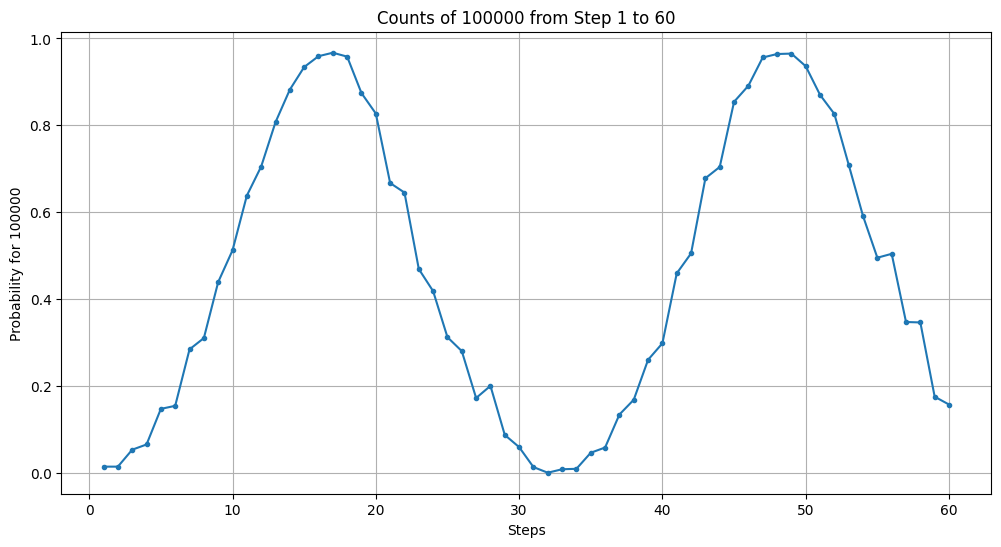

In [19]:
shots = 1000
max_steps = 60
target_state = '100000'

sampler = Sampler()

# Build a fresh circuit for a given number of steps
def build_walk_circuit(num_steps, l):
    qc = QuantumCircuit(nodeX, nodeY, coin, classR)
    
    

    # Initial state preparation
    qc.append(coin_prep, coin)
    superposition(qc)
    # Compute coefficients of the coin
    a = 2 / (4 + l)
    b = 2 * np.sqrt(l) / (4 + l)
    c = 2 * l / (4 + l)

    C5 = np.array([
        [a - 1,  a,      a,      a,      b],
        [a,      a - 1,  a,      a,      b],
        [a,      a,      a - 1,  a,      b],
        [a,      a,      a,      a - 1,  b],
        [b,      b,      b,      b,      c - 1]
    ], dtype=complex)

    # Embed into an 8x8 matrix for 3 qubits
    C8 = np.zeros((8, 8), dtype=complex)
    C8[:5, :5] = C5  # top-left block
    for i in range(5, 8):
        C8[i, i] = 1

    # Creating the gate for Coin
    coin_gate = UnitaryGate(C8, label="Coin")

    # Step 1
    qc.append(coin_gate, coin)
    shift(qc)
    qc.append(phase_circuit, [0, 1, 2, 3, 4, 5])

    # Remaining steps
    for _ in range(num_steps - 1):
        qc.append(coin_gate, [6, 7, 8])
        shift(qc)
        qc.append(phase_circuit, [0, 1, 2, 3, 4, 5])

    # Measure only the first 6 qubits
    qc.measure([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])

    return qc


steps = []
target_counts = []

for step in range(1, max_steps + 1):
    qc = build_walk_circuit(step, 0.0625)

    job = sampler.run([qc], shots=shots)
    result = job.result()

    counts = result[0].data.measure.get_counts()
    count_000000 = counts.get(target_state, 0)/1000

    steps.append(step)
    target_counts.append(count_000000)

    print(f"Step {step}: {target_state} -> {count_000000}")


# Plot the counts for 000000 from step 1 to 200
plt.figure(figsize=(12, 6))
plt.plot(steps, target_counts, marker='o', markersize=3)
plt.xlabel("Steps")
plt.ylabel(f"Probability for {target_state}")
plt.title(f"Counts of {target_state} from Step 1 to {max_steps}")
plt.grid(True)
plt.show()

In [20]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# ── Authenticate ───────────────────────────────────────────────────────────────
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="F7aJEdkTaWXHl1TOEZ3HS0b_Q1UJCBmrQONI1zcc3OUB",
    overwrite=True
)

# Load saved account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

qiskit_runtime_service.__init__:WARNING:2026-04-03 12:46:31,837: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [21]:
service = QiskitRuntimeService(channel="ibm_quantum_platform")
print(service.backends())

qiskit_runtime_service.__init__:WARNING:2026-04-03 12:46:42,429: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 12:46:42,430: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>]


Noisy with no error mitigarion 

qiskit_runtime_service.__init__:WARNING:2026-04-03 01:55:38,747: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 01:55:38,749: Using instance: open-instance, plan: open


Step 1: 100000 -> 11
Step 2: 100000 -> 22
Step 3: 100000 -> 16
Step 4: 100000 -> 11
Step 5: 100000 -> 18
Step 6: 100000 -> 15
Step 7: 100000 -> 17
Step 8: 100000 -> 17
Step 9: 100000 -> 17
Step 10: 100000 -> 19
Step 11: 100000 -> 12
Step 12: 100000 -> 21
Step 13: 100000 -> 21
Step 14: 100000 -> 17
Step 15: 100000 -> 23
Step 16: 100000 -> 12
Step 17: 100000 -> 20
Step 18: 100000 -> 17
Step 19: 100000 -> 14
Step 20: 100000 -> 14
Step 21: 100000 -> 15
Step 22: 100000 -> 15
Step 23: 100000 -> 13
Step 24: 100000 -> 18
Step 25: 100000 -> 15
Step 26: 100000 -> 14
Step 27: 100000 -> 22
Step 28: 100000 -> 19
Step 29: 100000 -> 16
Step 30: 100000 -> 19
Step 31: 100000 -> 19
Step 32: 100000 -> 26
Step 33: 100000 -> 17
Step 34: 100000 -> 13
Step 35: 100000 -> 17
Step 36: 100000 -> 16
Step 37: 100000 -> 17
Step 38: 100000 -> 16
Step 39: 100000 -> 23
Step 40: 100000 -> 14
Step 41: 100000 -> 28
Step 42: 100000 -> 16
Step 43: 100000 -> 18
Step 44: 100000 -> 8
Step 45: 100000 -> 16
Step 46: 100000 -> 2

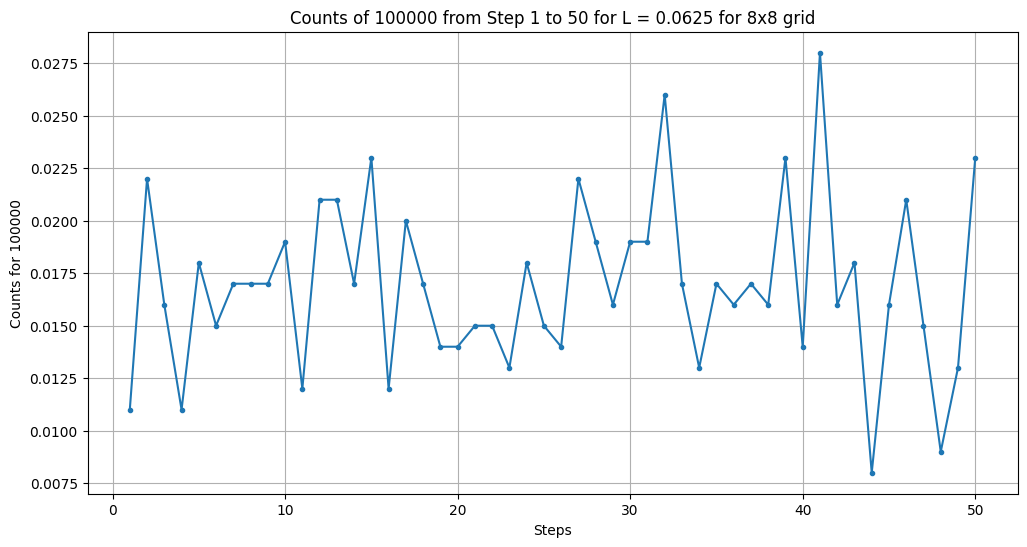

In [47]:
from qiskit_aer.noise import NoiseModel
shots = 1000
max_steps = 50
target_state = '100000'
service      = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")
noise_model  = NoiseModel.from_backend(real_backend)
noisy_sim    = AerSimulator(noise_model=noise_model)

#sampler = Sampler()

# Build a fresh circuit for a given number of steps
def build_walk_circuit(num_steps, l):
    qc = QuantumCircuit(nodeX, nodeY, coin, classR)
    coin_init = np.zeros(8, dtype=complex)
    coin_init[0] = 1 / np.sqrt(4 + l)           # 000
    coin_init[1] = 1 / np.sqrt(4 + l)           # 001
    coin_init[2] = 1 / np.sqrt(4 + l)           # 010
    coin_init[3] = 1 / np.sqrt(4 + l)           # 011
    coin_init[4] = np.sqrt(l) / np.sqrt(4 + l)  # 100

    coin_prep = StatePreparation(coin_init)

    # Initial state preparation
    qc.append(coin_prep, coin)
    superposition(qc)
    # Compute coefficients of the coin
    a = 2 / (4 + l)
    b = 2 * np.sqrt(l) / (4 + l)
    c = 2 * l / (4 + l)

    C5 = np.array([
        [a - 1,  a,      a,      a,      b],
        [a,      a - 1,  a,      a,      b],
        [a,      a,      a - 1,  a,      b],
        [a,      a,      a,      a - 1,  b],
        [b,      b,      b,      b,      c - 1]
    ], dtype=complex)

    # Embed into an 8x8 matrix for 3 qubits
    C8 = np.zeros((8, 8), dtype=complex)
    C8[:5, :5] = C5  # top-left block
    for i in range(5, 8):
        C8[i, i] = 1

    # Creating the gate for Coin
    coin_gate = UnitaryGate(C8, label="Coin")

    # Step 1
    qc.append(coin_gate, coin)
    shift(qc)
    qc.append(phase_circuit, [0, 1, 2, 3, 4, 5])

    # Remaining steps
    for _ in range(num_steps - 1):
        qc.append(coin_gate, [6, 7, 8])
        shift(qc)
        qc.append(phase_circuit, [0, 1, 2, 3, 4, 5])

    # Measure only the first 6 qubits
    qc.measure([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])

    return qc
l = 0.0625
while l<= 0.0625:
  steps = []
  target_counts = []

  for step in range(1, max_steps + 1):
      qc = build_walk_circuit(step, l)
      transpiled = transpile([qc], noisy_sim)
      result     = noisy_sim.run(transpiled, shots=shots).result()
      counts     = result.get_counts()


      #counts = result[0].data.measure.get_counts()
      count_000000 = counts.get(target_state, 0)

      steps.append(step)
      target_counts.append(count_000000/1000)

      print(f"Step {step}: {target_state} -> {count_000000}")


  # Plot the counts for 000000 from step 1 to 200
  plt.figure(figsize=(12, 6))
  plt.plot(steps, target_counts, marker='o', markersize=3)
  plt.xlabel("Steps")
  plt.ylabel(f"Counts for {target_state}")
  plt.title(f"Counts of {target_state} from Step 1 to {max_steps} for L = {l} for 8x8 grid")
  plt.grid(True)
  plt.savefig(f'histogram_l_{l:.4f}.png', dpi=300, bbox_inches='tight')
  plt.show()

  l = l + 0.001

ZNE

qiskit_runtime_service.__init__:WARNING:2026-04-03 12:48:11,376: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-03 12:48:11,377: Using instance: open-instance, plan: open
c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': True, 'zne': {'noise_factors': [1.0, 3.0, 5.0], 'extrapolator': 'polynomial_degree_2'}}} have no effect in local testing mode.
  warnings.warn(f"Options {optio

Step 1: ZNE Prob -> 0.015869


c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': True, 'zne': {'noise_factors': [1.0, 3.0, 5.0], 'extrapolator': 'polynomial_degree_2'}}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


Step 2: ZNE Prob -> 0.013916


c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': True, 'zne': {'noise_factors': [1.0, 3.0, 5.0], 'extrapolator': 'polynomial_degree_2'}}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


...

Step 48: ZNE Prob -> 0.018799


c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': True, 'zne': {'noise_factors': [1.0, 3.0, 5.0], 'extrapolator': 'polynomial_degree_2'}}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


Step 49: ZNE Prob -> 0.012695


c:\Users\nisha\AppData\Local\Programs\Python\Python314\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': True, 'zne': {'noise_factors': [1.0, 3.0, 5.0], 'extrapolator': 'polynomial_degree_2'}}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


Step 50: ZNE Prob -> 0.017090


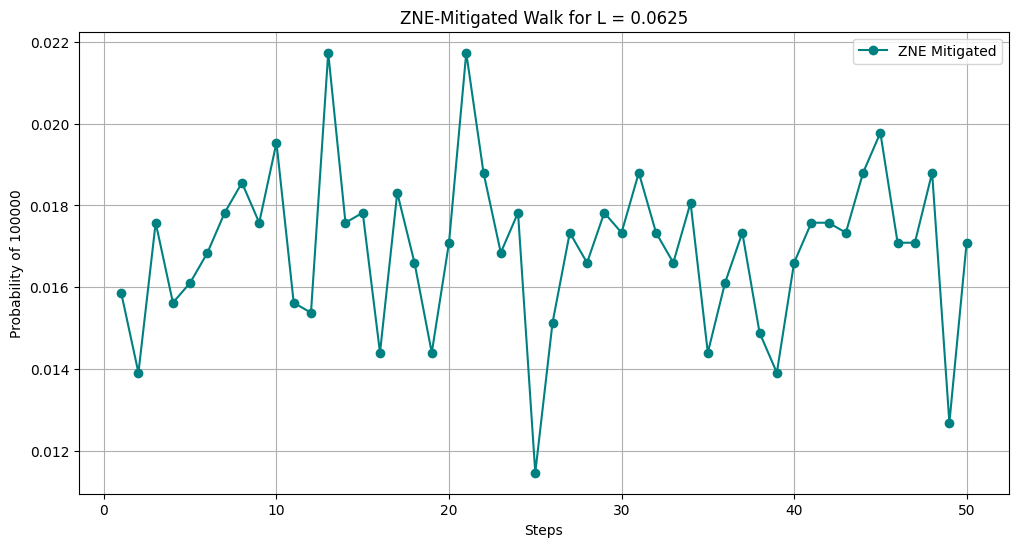

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# --- Setup ---
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

# Define the Projector for '100000' on the first 6 qubits
# Probability P = <ψ|M|ψ> where M = |100000><100000| ⊗ I...I
def get_zne_observable(total_qubits):
    # |0><0| = 0.5(I + Z), |1><1| = 0.5(I - Z)
    p0 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    p1 = SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    
    # Target bitstring '100000' (q5...q0)
    obs = p1.tensor(p0).tensor(p0).tensor(p0).tensor(p0).tensor(p0)
    
    # Pad for coin qubits (3 qubits)
    for _ in range(total_qubits - 6):
        obs = SparsePauliOp(["I"]).tensor(obs)
    return obs

# --- Estimator Configuration (ZNE Only) ---
estimator = Estimator(mode=noisy_sim)

# Disable suppression and other mitigation
estimator.options.dynamical_decoupling.enable = False
estimator.options.resilience.measure_mitigation = False

# Enable and Configure ZNE correctly
estimator.options.resilience.zne_mitigation = True
estimator.options.resilience.zne.noise_factors = [1, 3, 5]

# Use a specific degree for the polynomial fit (e.g., 2)
estimator.options.resilience.zne.extrapolator = "polynomial_degree_2"

# --- Main Execution Loop ---
l = 0.0625
max_steps = 50
target_state = '100000'
total_qubits = 9 # Adjust based on nodeX, nodeY, coin dimensions
observable = get_zne_observable(total_qubits)
pm = generate_preset_pass_manager(backend=noisy_sim, optimization_level=3)

steps = []
target_counts = []

while l <= 0.0625:
    for step in range(1, max_steps + 1):
        # NOTE: Ensure build_walk_circuit does NOT include qc.measure()
        qc = build_walk_circuit(step, l) 
        
        # Transpile to ISA
        isa_circuit = pm.run(qc)
        isa_observable = observable.apply_layout(isa_circuit.layout)
        
        # Run ZNE-mitigated Estimator
        pub = (isa_circuit, isa_observable)
        job = estimator.run([pub])
        result = job.result()[0]
        
        # Expectation value of the projector is the probability
        prob = result.data.evs
        
        steps.append(step)
        target_counts.append(prob)
        print(f"Step {step}: ZNE Prob -> {prob:.6f}")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(steps, target_counts, marker='o', color='teal', label='ZNE Mitigated')
    plt.xlabel("Steps")
    plt.ylabel(f"Probability of {target_state}")
    plt.title(f"ZNE-Mitigated Walk for L = {l}")
    plt.grid(True)
    plt.legend()
    plt.show()

    l += 0.001

qiskit_runtime_service.__init__:WARNING:2026-04-04 00:12:19,663: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-04 00:12:19,664: Using instance: open-instance, plan: open


Step 1: DD Prob -> 0.014160
Step 2: DD Prob -> 0.018066
Step 3: DD Prob -> 0.021240
Step 4: DD Prob -> 0.012207
Step 5: DD Prob -> 0.017578
Step 6: DD Prob -> 0.017822
Step 7: DD Prob -> 0.019043
Step 8: DD Prob -> 0.018555
Step 9: DD Prob -> 0.014648
Step 10: DD Prob -> 0.012939
Step 11: DD Prob -> 0.019775
Step 12: DD Prob -> 0.021484
Step 13: DD Prob -> 0.018066
Step 14: DD Prob -> 0.016602
Step 15: DD Prob -> 0.018311
Step 16: DD Prob -> 0.019531
Step 17: DD Prob -> 0.019287
Step 18: DD Prob -> 0.014404
Step 19: DD Prob -> 0.013916
Step 20: DD Prob -> 0.017334
Step 21: DD Prob -> 0.015381
Step 22: DD Prob -> 0.016602
Step 23: DD Prob -> 0.015137
Step 24: DD Prob -> 0.018311
Step 25: DD Prob -> 0.012939
Step 26: DD Prob -> 0.016846
Step 27: DD Prob -> 0.012939
Step 28: DD Prob -> 0.018066
Step 29: DD Prob -> 0.019043
Step 30: DD Prob -> 0.017090
Step 31: DD Prob -> 0.014893
Step 32: DD Prob -> 0.015381
Step 33: DD Prob -> 0.015381
Step 34: DD Prob -> 0.019531
Step 35: DD Prob -> 0.0

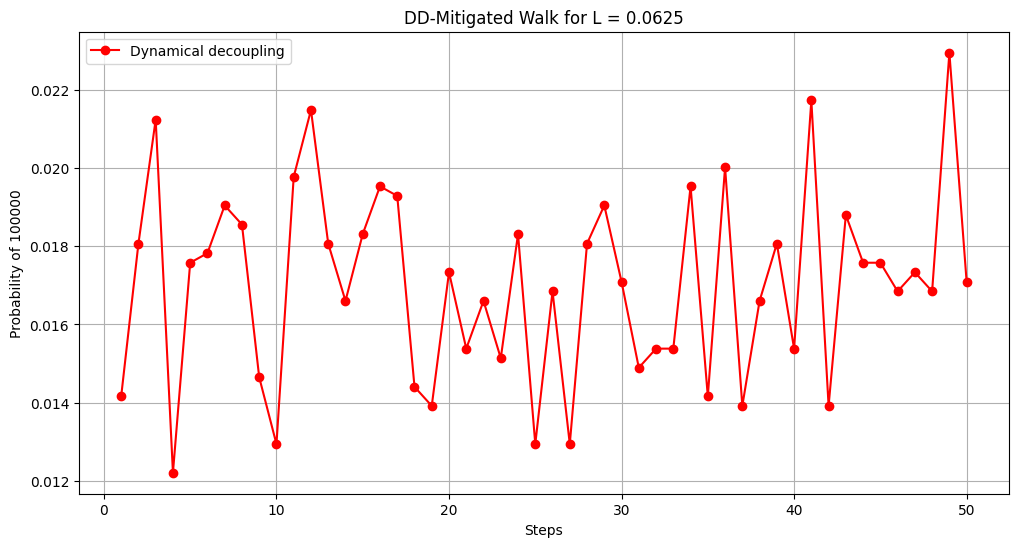

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import warnings
warnings.filterwarnings('ignore')


# --- Setup ---
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

# Define the Projector for '100000' on the first 6 qubits
# Probability P = <ψ|M|ψ> where M = |100000><100000| ⊗ I...I
def get_zne_observable(total_qubits):
    # |0><0| = 0.5(I + Z), |1><1| = 0.5(I - Z)
    p0 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    p1 = SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    
    # Target bitstring '100000' (q5...q0)
    obs = p1.tensor(p0).tensor(p0).tensor(p0).tensor(p0).tensor(p0)
    
    # Pad for coin qubits (3 qubits)
    for _ in range(total_qubits - 6):
        obs = SparsePauliOp(["I"]).tensor(obs)
    return obs

# --- Estimator Configuration (ZNE Only) ---
estimator = Estimator(mode=noisy_sim)

# Disable suppression and other mitigation
estimator.options.dynamical_decoupling.enable = True
estimator.options.dynamical_decoupling.sequence_type = "XpXm"

# Enable and Configure ZNE correctly
#estimator.options.resilience.zne_mitigation = False
#estimator.options.resilience.zne.noise_factors = [1, 3, 5]

# Use a specific degree for the polynomial fit (e.g., 2)
#stimator.options.resilience.zne.extrapolator = "polynomial_degree_2"

# --- Main Execution Loop ---
l = 0.0625
max_steps = 50
target_state = '100000'
total_qubits = 9 # Adjust based on nodeX, nodeY, coin dimensions
observable = get_zne_observable(total_qubits)
pm = generate_preset_pass_manager(backend=noisy_sim, optimization_level=3)

steps = []
target_counts = []

while l <= 0.0625:
    for step in range(1, max_steps + 1):
        # NOTE: Ensure build_walk_circuit does NOT include qc.measure()
        qc = build_walk_circuit(step, l) 
        
        # Transpile to ISA
        isa_circuit = pm.run(qc)
        isa_observable = observable.apply_layout(isa_circuit.layout)
        
        # Run ZNE-mitigated Estimator
        pub = (isa_circuit, isa_observable)
        job = estimator.run([pub])
        result = job.result()[0]
        
        # Expectation value of the projector is the probability
        prob = result.data.evs
        
        steps.append(step)
        target_counts.append(prob)
        print(f"Step {step}: DD Prob -> {prob:.6f}")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(steps, target_counts, marker='o', color='red', label='Dynamical decoupling')
    plt.xlabel("Steps")
    plt.ylabel(f"Probability of {target_state}")
    plt.title(f"DD-Mitigated Walk for L = {l}")
    plt.grid(True)
    plt.legend()
    plt.show()

    l += 0.001

qiskit_runtime_service.__init__:WARNING:2026-04-04 00:44:31,086: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-04 00:44:31,088: Using instance: open-instance, plan: open


Step 1: TREX Prob -> 0.014648
Step 2: TREX Prob -> 0.011963
Step 3: TREX Prob -> 0.016602
Step 4: TREX Prob -> 0.019287
Step 5: TREX Prob -> 0.016357
Step 6: TREX Prob -> 0.014404
Step 7: TREX Prob -> 0.017822
Step 8: TREX Prob -> 0.014404
Step 9: TREX Prob -> 0.015381
Step 10: TREX Prob -> 0.016113
Step 11: TREX Prob -> 0.016113
Step 12: TREX Prob -> 0.012207
Step 13: TREX Prob -> 0.016113
Step 14: TREX Prob -> 0.014160
Step 15: TREX Prob -> 0.014404
Step 16: TREX Prob -> 0.015137
Step 17: TREX Prob -> 0.015137
Step 18: TREX Prob -> 0.017090
Step 19: TREX Prob -> 0.018311
Step 20: TREX Prob -> 0.020264
Step 21: TREX Prob -> 0.016846
Step 22: TREX Prob -> 0.018066
Step 23: TREX Prob -> 0.019775
Step 24: TREX Prob -> 0.017090
Step 25: TREX Prob -> 0.016113
Step 26: TREX Prob -> 0.018799
Step 27: TREX Prob -> 0.013672
Step 28: TREX Prob -> 0.013916
Step 29: TREX Prob -> 0.018799
Step 30: TREX Prob -> 0.016113
Step 31: TREX Prob -> 0.015381
Step 32: TREX Prob -> 0.015381
Step 33: TREX Pro

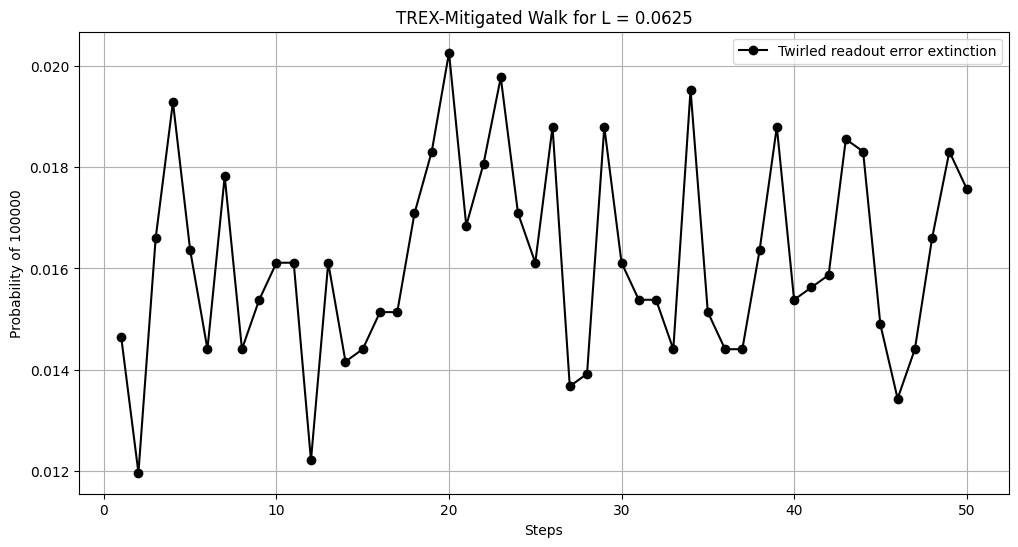

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import warnings
warnings.filterwarnings('ignore')


# --- Setup ---
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

# Define the Projector for '100000' on the first 6 qubits
# Probability P = <ψ|M|ψ> where M = |100000><100000| ⊗ I...I
def get_zne_observable(total_qubits):
    # |0><0| = 0.5(I + Z), |1><1| = 0.5(I - Z)
    p0 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    p1 = SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    
    # Target bitstring '100000' (q5...q0)
    obs = p1.tensor(p0).tensor(p0).tensor(p0).tensor(p0).tensor(p0)
    
    # Pad for coin qubits (3 qubits)
    for _ in range(total_qubits - 6):
        obs = SparsePauliOp(["I"]).tensor(obs)
    return obs

# --- Estimator Configuration (ZNE Only) ---
estimator = Estimator(mode=noisy_sim)

# Disable suppression and other mitigation
estimator.options.resilience.measure_mitigation = True
estimator.options.resilience.measure_noise_learning.num_randomizations = 32
estimator.options.resilience.measure_noise_learning.shots_per_randomization = 100

# Enable and Configure ZNE correctly
#estimator.options.resilience.zne_mitigation = False
#estimator.options.resilience.zne.noise_factors = [1, 3, 5]

# Use a specific degree for the polynomial fit (e.g., 2)
#stimator.options.resilience.zne.extrapolator = "polynomial_degree_2"

# --- Main Execution Loop ---
l = 0.0625
max_steps = 50
target_state = '100000'
total_qubits = 9 # Adjust based on nodeX, nodeY, coin dimensions
observable = get_zne_observable(total_qubits)
pm = generate_preset_pass_manager(backend=noisy_sim, optimization_level=3)

steps = []
target_counts = []

while l <= 0.0625:
    for step in range(1, max_steps + 1):
        # NOTE: Ensure build_walk_circuit does NOT include qc.measure()
        qc = build_walk_circuit(step, l) 
        
        # Transpile to ISA
        isa_circuit = pm.run(qc)
        isa_observable = observable.apply_layout(isa_circuit.layout)
        
        # Run ZNE-mitigated Estimator
        pub = (isa_circuit, isa_observable)
        job = estimator.run([pub])
        result = job.result()[0]
        
        # Expectation value of the projector is the probability
        prob = result.data.evs
        
        steps.append(step)
        target_counts.append(prob)
        print(f"Step {step}: TREX Prob -> {prob:.6f}")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(steps, target_counts, marker='o', color='black', label='Twirled readout error extinction')
    plt.xlabel("Steps")
    plt.ylabel(f"Probability of {target_state}")
    plt.title(f"TREX-Mitigated Walk for L = {l}")
    plt.grid(True)
    plt.legend()
    plt.show()

    l += 0.001

qiskit_runtime_service.__init__:WARNING:2026-04-04 09:32:08,773: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-04 09:32:08,782: Using instance: open-instance, plan: open


Step 1: PEA Prob -> 0.017578
Step 2: PEA Prob -> 0.016846
Step 3: PEA Prob -> 0.018799
Step 4: PEA Prob -> 0.014893
Step 5: PEA Prob -> 0.020264
Step 6: PEA Prob -> 0.018799
Step 7: PEA Prob -> 0.014648
Step 8: PEA Prob -> 0.017334
Step 9: PEA Prob -> 0.016602
Step 10: PEA Prob -> 0.017578
Step 11: PEA Prob -> 0.019287
Step 12: PEA Prob -> 0.020996
Step 13: PEA Prob -> 0.015625
Step 14: PEA Prob -> 0.018311
Step 15: PEA Prob -> 0.013916
Step 16: PEA Prob -> 0.013184
Step 17: PEA Prob -> 0.016602
Step 18: PEA Prob -> 0.019531
Step 19: PEA Prob -> 0.014893
Step 20: PEA Prob -> 0.019531
Step 21: PEA Prob -> 0.015137
Step 22: PEA Prob -> 0.016602
Step 23: PEA Prob -> 0.019775
Step 24: PEA Prob -> 0.013428
Step 25: PEA Prob -> 0.020264
Step 26: PEA Prob -> 0.018311
Step 27: PEA Prob -> 0.018799
Step 28: PEA Prob -> 0.016357
Step 29: PEA Prob -> 0.013916
Step 30: PEA Prob -> 0.017090
Step 31: PEA Prob -> 0.017822
Step 32: PEA Prob -> 0.016357
Step 33: PEA Prob -> 0.016846
Step 34: PEA Prob -

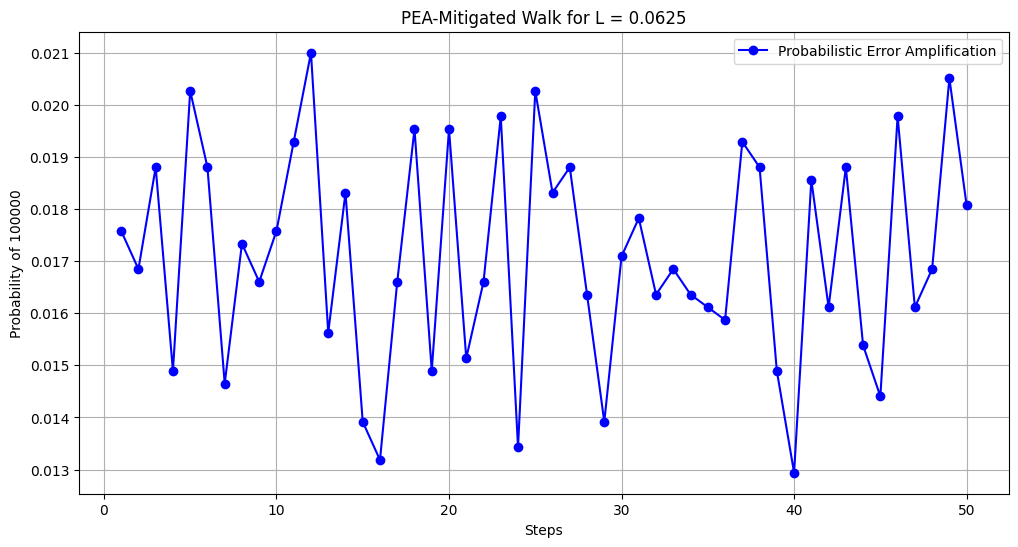

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import warnings
warnings.filterwarnings('ignore')


# --- Setup ---
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

# Define the Projector for '100000' on the first 6 qubits
# Probability P = <ψ|M|ψ> where M = |100000><100000| ⊗ I...I
def get_zne_observable(total_qubits):
    # |0><0| = 0.5(I + Z), |1><1| = 0.5(I - Z)
    p0 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    p1 = SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    
    # Target bitstring '100000' (q5...q0)
    obs = p1.tensor(p0).tensor(p0).tensor(p0).tensor(p0).tensor(p0)
    
    # Pad for coin qubits (3 qubits)
    for _ in range(total_qubits - 6):
        obs = SparsePauliOp(["I"]).tensor(obs)
    return obs

# --- Estimator Configuration (ZNE Only) ---
estimator = Estimator(mode=noisy_sim)

# Disable suppression and other mitigation
estimator.options.resilience.zne_mitigation = True
estimator.options.resilience.zne.amplifier = "pea"

# Enable and Configure ZNE correctly
#estimator.options.resilience.zne_mitigation = False
#estimator.options.resilience.zne.noise_factors = [1, 3, 5]

# Use a specific degree for the polynomial fit (e.g., 2)
#stimator.options.resilience.zne.extrapolator = "polynomial_degree_2"

# --- Main Execution Loop ---
l = 0.0625
max_steps = 50
target_state = '100000'
total_qubits = 9 # Adjust based on nodeX, nodeY, coin dimensions
observable = get_zne_observable(total_qubits)
pm = generate_preset_pass_manager(backend=noisy_sim, optimization_level=3)

steps = []
target_counts = []

while l <= 0.0625:
    for step in range(1, max_steps + 1):
        # NOTE: Ensure build_walk_circuit does NOT include qc.measure()
        qc = build_walk_circuit(step, l) 
        
        # Transpile to ISA
        isa_circuit = pm.run(qc)
        isa_observable = observable.apply_layout(isa_circuit.layout)
        
        # Run ZNE-mitigated Estimator
        pub = (isa_circuit, isa_observable)
        job = estimator.run([pub])
        result = job.result()[0]
        
        # Expectation value of the projector is the probability
        prob = result.data.evs
        
        steps.append(step)
        target_counts.append(prob)
        print(f"Step {step}: PEA Prob -> {prob:.6f}")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(steps, target_counts, marker='o', color='blue', label='Probabilistic Error Amplification')
    plt.xlabel("Steps")
    plt.ylabel(f"Probability of {target_state}")
    plt.title(f"PEA-Mitigated Walk for L = {l}")
    plt.grid(True)
    plt.legend()
    plt.show()

    l += 0.001

qiskit_runtime_service.__init__:WARNING:2026-04-04 09:53:07,029: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-04 09:53:07,030: Using instance: open-instance, plan: open


Step 1: PEC  Prob -> 0.014893
Step 2: PEC  Prob -> 0.017822
Step 3: PEC  Prob -> 0.019775
Step 4: PEC  Prob -> 0.018066
Step 5: PEC  Prob -> 0.018799
Step 6: PEC  Prob -> 0.013672
Step 7: PEC  Prob -> 0.022461
Step 8: PEC  Prob -> 0.016602
Step 9: PEC  Prob -> 0.014160
Step 10: PEC  Prob -> 0.016357
Step 11: PEC  Prob -> 0.014160
Step 12: PEC  Prob -> 0.018555
Step 13: PEC  Prob -> 0.015381
Step 14: PEC  Prob -> 0.017822
Step 15: PEC  Prob -> 0.015625
Step 16: PEC  Prob -> 0.014404
Step 17: PEC  Prob -> 0.016846
Step 18: PEC  Prob -> 0.017334
Step 19: PEC  Prob -> 0.016113
Step 20: PEC  Prob -> 0.018555
Step 21: PEC  Prob -> 0.016113
Step 22: PEC  Prob -> 0.015869
Step 23: PEC  Prob -> 0.015869
Step 24: PEC  Prob -> 0.018555
Step 25: PEC  Prob -> 0.017090
Step 26: PEC  Prob -> 0.016602
Step 27: PEC  Prob -> 0.020996
Step 28: PEC  Prob -> 0.015137
Step 29: PEC  Prob -> 0.017822
Step 30: PEC  Prob -> 0.014160
Step 31: PEC  Prob -> 0.017578
Step 32: PEC  Prob -> 0.017578
Step 33: PEC  Pro

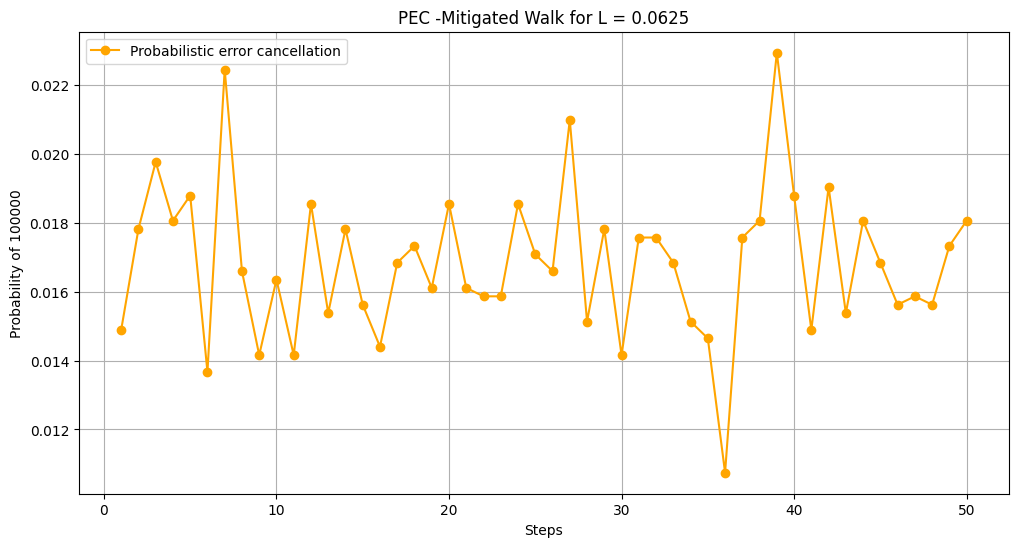

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import warnings
warnings.filterwarnings('ignore')


# --- Setup ---
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
noisy_sim = AerSimulator(noise_model=noise_model)

# Define the Projector for '100000' on the first 6 qubits
# Probability P = <ψ|M|ψ> where M = |100000><100000| ⊗ I...I
def get_zne_observable(total_qubits):
    # |0><0| = 0.5(I + Z), |1><1| = 0.5(I - Z)
    p0 = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    p1 = SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    
    # Target bitstring '100000' (q5...q0)
    obs = p1.tensor(p0).tensor(p0).tensor(p0).tensor(p0).tensor(p0)
    
    # Pad for coin qubits (3 qubits)
    for _ in range(total_qubits - 6):
        obs = SparsePauliOp(["I"]).tensor(obs)
    return obs

# --- Estimator Configuration (ZNE Only) ---
estimator = Estimator(mode=noisy_sim)

# Disable suppression and other mitigation
estimator.options.simulator.coupling_map = real_backend.coupling_map
estimator.options.resilience.pec_mitigation = True
estimator.options.resilience.pec.max_overhead = 100

# Enable and Configure ZNE correctly
#estimator.options.resilience.zne_mitigation = False
#estimator.options.resilience.zne.noise_factors = [1, 3, 5]

# Use a specific degree for the polynomial fit (e.g., 2)
#stimator.options.resilience.zne.extrapolator = "polynomial_degree_2"

# --- Main Execution Loop ---
l = 0.0625
max_steps = 50
target_state = '100000'
total_qubits = 9 # Adjust based on nodeX, nodeY, coin dimensions
observable = get_zne_observable(total_qubits)
pm = generate_preset_pass_manager(backend=noisy_sim, optimization_level=3)

steps = []
target_counts = []

while l <= 0.0625:
    for step in range(1, max_steps + 1):
        # NOTE: Ensure build_walk_circuit does NOT include qc.measure()
        qc = build_walk_circuit(step, l) 
        
        # Transpile to ISA
        isa_circuit = pm.run(qc)
        isa_observable = observable.apply_layout(isa_circuit.layout)
        
        # Run ZNE-mitigated Estimator
        pub = (isa_circuit, isa_observable)
        job = estimator.run([pub])
        result = job.result()[0]
        
        # Expectation value of the projector is the probability
        prob = result.data.evs
        
        steps.append(step)
        target_counts.append(prob)
        print(f"Step {step}: PEC  Prob -> {prob:.6f}")

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(steps, target_counts, marker='o', color='orange', label='Probabilistic error cancellation')
    plt.xlabel("Steps")
    plt.ylabel(f"Probability of {target_state}")
    plt.title(f"PEC -Mitigated Walk for L = {l}")
    plt.grid(True)
    plt.legend()
    plt.show()

    l += 0.001